In [1]:
import numpy as np
import matplotlib.pyplot as plt
from utils import *

In [2]:
opsin_nm = np.load("opsins/wavelengths_nm.npz")["nm"]
human_opsin = np.load("opsins/human_SML.npz")
sts_nm = np.load('opsins/STS_nm.npy')

In [19]:
def vline_max(x,y,c):
    max_nm = x[np.argmax(y)]
    label_nm = int(max_nm)
    plt.vlines(max_nm,0,1,color=c,label='{} nm'.format(label_nm))

## inspect the human opsin files

In [20]:
red_ =nan2zero(human_opsin['l']);print(red_.shape)
green_ =nan2zero(human_opsin['m']);print(green_.shape)
blue_ =nan2zero(human_opsin['s']);print(blue_.shape)

(2048,)
(2048,)
(2048,)


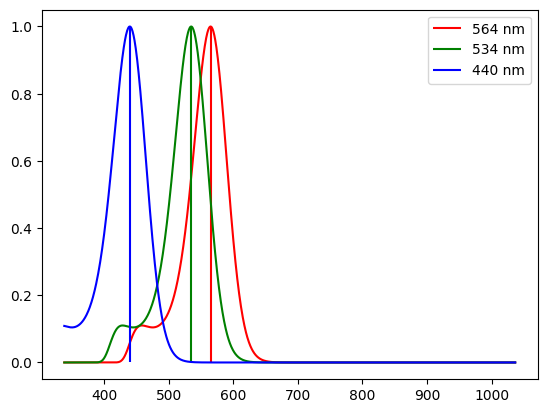

In [21]:
plt.plot(opsin_nm,red_,color='r')
vline_max(opsin_nm,red_,'r')
plt.plot(opsin_nm,green_,color='g')
vline_max(opsin_nm,green_,'g')
plt.plot(opsin_nm,blue_,color='blue')
vline_max(opsin_nm,blue_,'blue')
plt.legend()

In [22]:
np.min(opsin_nm)

338.6034821

In [23]:
np.min(sts_nm)

182.79051208496094

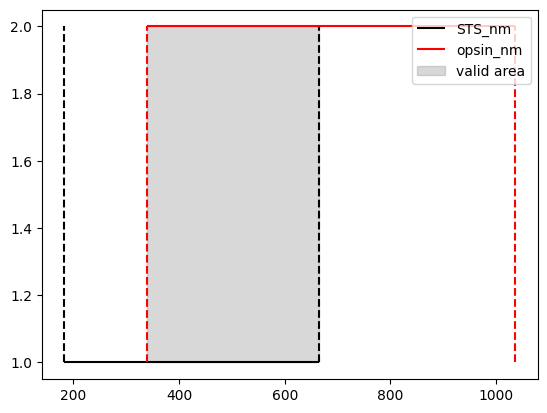

In [51]:
plt.hlines(1,np.min(sts_nm),np.max(sts_nm),color='k',label='STS_nm')
plt.vlines(np.min(sts_nm),1,2,color='k',linestyle='dashed')
plt.vlines(np.max(sts_nm),1,2,color='k',linestyle='dashed')

plt.hlines(2,np.min(opsin_nm),np.max(opsin_nm),color='r',label='opsin_nm')
plt.vlines(np.min(opsin_nm),1,2,color='r',linestyle='dashed')
plt.vlines(np.max(opsin_nm),1,2,color='r',linestyle='dashed')

plt.fill_betweenx([1,2],np.min(opsin_nm),np.max(sts_nm),color='gray',alpha=.3,label='valid area')
plt.legend()

### calculate the valid area for both wavelength data

In [52]:
overlap_sts_idx = sts_nm>np.min(opsin_nm)
overlap_sts_nm = sts_nm[overlap_sts_idx]
print(overlap_sts_nm.shape)

(683,)


In [53]:
overlap_opsin_idx = opsin_nm<np.max(sts_nm)
overlap_opsin_nm = opsin_nm[overlap_opsin_idx]
print(overlap_opsin_nm.shape)

(887,)


In [36]:
def print_miax(x):
    print(np.min(x),np.max(x))

In [55]:
print_miax(overlap_sts_nm)
print_miax(overlap_opsin_nm)

339.04323226637973 665.6025696758672
338.6034821 665.4365390166926


In [58]:
red = red_[overlap_opsin_idx]
green = green_[overlap_opsin_idx]
blue = blue_[overlap_opsin_idx]

Text(0.5, 1.0, 'human opsin in the overlap wavelength area')

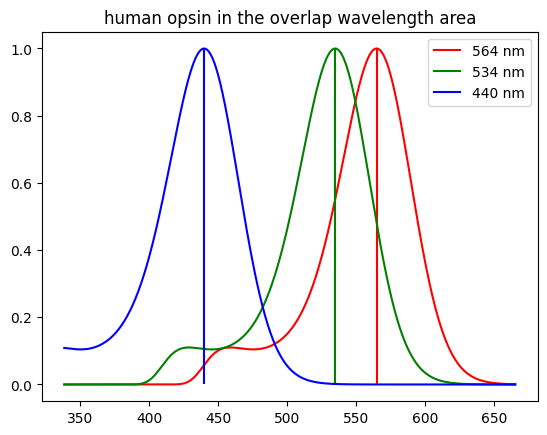

In [60]:
plt.plot(overlap_opsin_nm,red,color='r')
vline_max(overlap_opsin_nm,red,'r')
plt.plot(overlap_opsin_nm,green,color='g')
vline_max(overlap_opsin_nm,green,'g')
plt.plot(overlap_opsin_nm,blue,color='blue')
vline_max(overlap_opsin_nm,blue,'blue')
plt.legend()
plt.title("human opsin in the overlap wavelength area")

## save the data

In [61]:
from stimugenerator import dataIO

In [62]:
human_opsin_valid_range = {}

In [68]:
human_opsin_valid_range['s'] = blue
human_opsin_valid_range['m'] = green
human_opsin_valid_range['l'] = red
human_opsin_valid_range['nm'] = overlap_opsin_nm
human_opsin_valid_range['idx'] = overlap_opsin_idx
human_opsin_valid_range['sts_nm'] = overlap_sts_nm
human_opsin_valid_range['sts_idx'] = overlap_sts_idx

In [69]:
human_opsin_valid_range.keys()

dict_keys(['s', 'm', 'l', 'nm', 'idx', 'sts_nm', 'sts_idx'])

In [70]:
dataIO.makePickle('./opsins/human_SML_valid_NM.pkl',human_opsin_valid_range)